# 🚗⚡ EDA: Vehículos Eléctricos (EV) vs Combustión (ICE)

---

**Objetivo:** Explorar cómo han evolucionado los vehículos eléctricos frente a los de combustión interna en términos de emisiones de CO₂, autonomía y eficiencia energética.

### 📋 Información del dataset

| | |
|---|---|
| **Dataset** | EV vs ICE Vehicle Specs 2015–2026 |
| **Filas** | 15.301 |
| **Columnas** | 14 |
| **Plataforma de descarga** | Kaggle |
| **Fuente** | fueleconomy.gov (EPA — U.S. Department of Energy) |
| **Período** | 2015–2026 |

### ⚠️ Limitaciones del análisis

- El dataset recoge modelos certificados por la EPA, no unidades 
  vendidas, por lo que no refleja cuota de mercado real.
  
- Los datos de 2025 y 2026 corresponden a modelos ya homologados 
  pero que pueden no estar aún disponibles en el mercado en el 
  momento del análisis.
  
- Las emisiones de CO₂ de los EV son 0 en el punto de uso pero 
  no en términos de ciclo de vida completo — dependen del mix 
  energético del país donde se carguen.
  
- El dataset tiene sesgo geográfico hacia el mercado americano 
  (EE.UU.), por lo que los modelos disponibles y sus 
  especificaciones pueden diferir del mercado europeo.


---

<br><br>
## 1. Importación librerías

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sys
sys.path.append('../src/utils')
from utils import (calcular_outliers, mejora_relativa, mann_whitney_categorias, plot_distribucion, resumen_por_categoria)


<br><br>
## 2. Carga y exploración del dataset

In [ ]:
df_coches = pd.read_csv("./src/data/coches.csv")
df_coches.head(20)

,Make,Model,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,Transmission,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category
0,Nissan,GT-R,2015,Premium Gasoline,6.0,3.8,All-Wheel Drive,Automatic (AM6),16,23,19,472,0,ICE (Gas)
1,Volvo,S60 AWD,2015,Regular Gasoline,5.0,2.5,All-Wheel Drive,Automatic (S6),20,28,23,378,0,ICE (Gas)
2,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),26,37,30,298,0,ICE (Gas)
3,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),28,39,32,280,0,ICE (Gas)
4,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Manual 6-spd,25,35,29,308,0,ICE (Gas)
5,Kia,K900,2015,Regular Gasoline,6.0,3.8,Rear-Wheel Drive,Automatic 8-spd,18,26,21,428,0,ICE (Gas)
6,Kia,K900,2015,Premium Gasoline,8.0,5.0,Rear-Wheel Drive,Automatic 8-spd,15,23,18,494,0,ICE (Gas)
7,Kia,Sorento FWD,2015,Regular Gasoline,6.0,3.3,Front-Wheel Drive,Automatic 6-spd,18,25,21,427,0,ICE (Gas)
8,Mazda,CX-5 2WD,2015,Regular Gasoline,4.0,2.0,Front-Wheel Drive,Automatic (S6),26,32,28,311,0,ICE (Gas)
9,Mazda,CX-5 2WD,2015,Regular Gasoline,4.0,2.0,Front-Wheel Drive,Manual 6-spd,26,34,29,306,0,ICE (Gas)


In [3]:
df_coches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15301 entries, 0 to 15300
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      15301 non-null  object 
 1   Model                     15301 non-null  object 
 2   Year                      15301 non-null  int64  
 3   Fuel_Type                 15300 non-null  object 
 4   Engine_Cylinders          15301 non-null  float64
 5   Engine_Size_L             15301 non-null  float64
 6   Drivetrain                15301 non-null  object 
 7   Transmission              15301 non-null  object 
 8   City_MPG                  15301 non-null  int64  
 9   Highway_MPG               15301 non-null  int64  
 10  Combined_MPG              15301 non-null  int64  
 11  CO2_Emissions_g_per_mile  15301 non-null  int64  
 12  EV_Range_miles            15301 non-null  int64  
 13  Vehicle_Category          15301 non-null  object 
dtypes: flo

In [4]:
df_coches.shape

(15301, 14)

<br><br>
## 3. Limpieza de datos

Como solo hay una fila con nulo, vamos a eliminarla

In [5]:
df = df_coches.copy()
df = df.dropna()
df.shape

(15300, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15300 entries, 0 to 15300
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      15300 non-null  object 
 1   Model                     15300 non-null  object 
 2   Year                      15300 non-null  int64  
 3   Fuel_Type                 15300 non-null  object 
 4   Engine_Cylinders          15300 non-null  float64
 5   Engine_Size_L             15300 non-null  float64
 6   Drivetrain                15300 non-null  object 
 7   Transmission              15300 non-null  object 
 8   City_MPG                  15300 non-null  int64  
 9   Highway_MPG               15300 non-null  int64  
 10  Combined_MPG              15300 non-null  int64  
 11  CO2_Emissions_g_per_mile  15300 non-null  int64  
 12  EV_Range_miles            15300 non-null  int64  
 13  Vehicle_Category          15300 non-null  object 
dtypes: float64(

Nos falta comprobar si hay duplicados

In [7]:
print(f"Filas totales: {len(df)}")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"Filas únicas: {df.drop_duplicates().shape[0]}")

Filas totales: 15300
Filas duplicadas: 0
Filas únicas: 15300


<br><br>
## 4. Descripción de variables

| Columna/Variable | Descripción | Anotación |
| ---------------- | ----------- | --------- |
| Make | Marca del fabricante del vehículo|
| Model | Nombre del modelo específico del vehículo|
| Year | Año del modelo del vehículo |
| Fuel_Type | Tipo de combustible utilizado |
| Engine_Cylinders | Número de cilindros del motor | Vale 0 en los vehiculos eléctricos|
| Engine_Size_L | Cilindrada del motor expresada en litros | Vale 0 en los vehiculos eléctricos|
| Drivetrain | Sistema de tracción del vehículo |
| Transmission | Tipo de transmisión |
| City_MPG | Eficiencia en ciudad, expresada en millas por galón|
| Highway_MPG | Eficencia en carretera, expresada en millas por galón|
| Combined_MPG| Eficencia combinada (ciudad + carretera), expresada en millas por galón|
| CO2_Emissions_g_per_mile | Emisiones de CO2 expresada en gramos por milla recorrida|
| EV_Range_miles | Autonomía del vehículo eléctrico con una carga completa expresada en millas| Vale 0 en los vehiculos de combustión|
| Vehicle_Category | Clasificación de vehiculos||



<br><br>
## 5. Clasificación variables

In [8]:
df_tipificacion = pd.DataFrame([df.nunique(), df.nunique()/len(df)*100, df.dtypes]).T.rename(columns={0:"Card", 1:"%_Card",2:"Tipo"})
df_tipificacion.head(14)

,Card,%_Card,Tipo
Make,63,0.411765,object
Model,3078,20.117647,object
Year,12,0.078431,int64
Fuel_Type,7,0.045752,object
Engine_Cylinders,10,0.065359,float64
Engine_Size_L,54,0.352941,float64
Drivetrain,5,0.03268,object
Transmission,34,0.222222,object
City_MPG,140,0.915033,int64
Highway_MPG,125,0.816993,int64


In [9]:
df_tipificacion["Clasificada_como"] = "Categórica"
df_tipificacion.loc[df_tipificacion.Card == 2, "Clasificada_como"] = "Binaria"

# Solo aplicar reglas numéricas a columnas que no sean texto (object)
mask_num = df_tipificacion["Tipo"] != "object"
df_tipificacion.loc[mask_num & (df_tipificacion.Card > 10), "Clasificada_como"] = "Numérica Discreta"
df_tipificacion.loc[mask_num & (df_tipificacion["%_Card"] > 25), "Clasificada_como"] = "Numérica Continua"

# Texto con alta cardinalidad → no es numérica, es categórica especial
df_tipificacion.loc[
    (df_tipificacion.Tipo == "object") & (df_tipificacion.Card > 10),
    "Clasificada_como"
] = "Categórica (alta cardinalidad)"

df_tipificacion

,Card,%_Card,Tipo,Clasificada_como
Make,63,0.411765,object,Categórica (alta cardinalidad)
Model,3078,20.117647,object,Categórica (alta cardinalidad)
Year,12,0.078431,int64,Numérica Discreta
Fuel_Type,7,0.045752,object,Categórica
Engine_Cylinders,10,0.065359,float64,Categórica
Engine_Size_L,54,0.352941,float64,Numérica Discreta
Drivetrain,5,0.03268,object,Categórica
Transmission,34,0.222222,object,Categórica (alta cardinalidad)
City_MPG,140,0.915033,int64,Numérica Discreta
Highway_MPG,125,0.816993,int64,Numérica Discreta


Vamos a pasar a categóricas aquellas variables tipificadas como tal

In [10]:
# Identificar columnas categóricas según la tipificación
categoricas = df_tipificacion[df_tipificacion["Clasificada_como"].str.contains("Categórica")].index.tolist()
print("Columnas categóricas:", categoricas)

# Convertir a tipo category
for col in categoricas:
    df[col] = df[col].astype("category")

# Verificar el cambio
df[categoricas].dtypes



Columnas categóricas: ['Make', 'Model', 'Fuel_Type', 'Engine_Cylinders', 'Drivetrain', 'Transmission', 'Vehicle_Category']


Make                category
Model               category
Fuel_Type           category
Engine_Cylinders    category
Drivetrain          category
Transmission        category
Vehicle_Category    category
dtype: object

<br><br>
## 6. Análisis

El objetivo de este EDA es responder las siguientes preguntas:
- ¿Ha crecido la fabricación de vehículos eléctricos entre 2015 y 2026?
- ¿Cuánto CO₂ emite un ICE vs un EV en promedio?
- ¿Ha mejorado la autonomía de los EV con los años?
- ¿Qué marcas fabrican más vehículos eléctricos?
- ¿Los híbridos son realmente más eficientes que los de gasolina?

Con lo cual nos interesa trabajar con las siguientes variables:
- Vehicle_Category
- CO2_Emissions_g_per_mile
- Year
- EV_Range_miles
- Combined_MPG
- Make

<br><br>
- ### 6.1 - Variables Categóricas (Vehicle_Category)

- - #### Vehicle_Category

In [11]:
df["Vehicle_Category"].mode()

0    ICE (Gas)
Name: Vehicle_Category, dtype: category
Categories (5, object): ['CNG', 'EV', 'Hybrid/Other', 'ICE (Diesel)', 'ICE (Gas)']

In [12]:
distribucion = pd.DataFrame({
    'Valor absoluto': df['Vehicle_Category'].value_counts(),
    'Porcentaje': round(
        df['Vehicle_Category']
        .value_counts(normalize=True) * 100,
        2
    )
})

distribucion

,Valor absoluto,Porcentaje
Vehicle_Category,,
ICE (Gas),13589,88.82
EV,1361,8.90
ICE (Diesel),308,2.01
Hybrid/Other,41,0.27
CNG,1,0.01


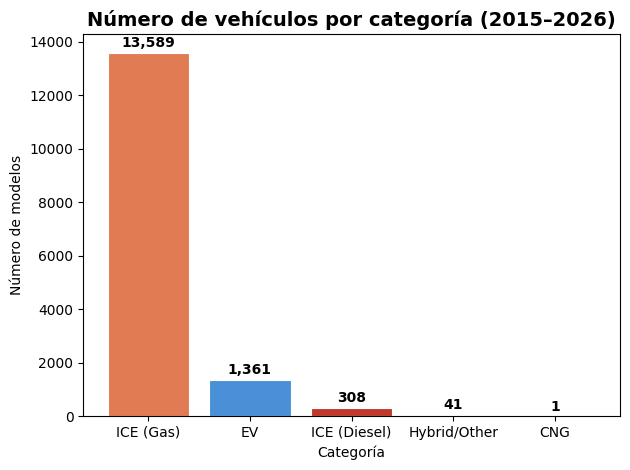

In [ ]:
colores = {'ICE (Gas)': '#E07B54', 'EV': '#4A90D9', 
           'ICE (Diesel)': '#C0392B', 'Hybrid/Other': '#27AE60', 'CNG': '#8E44AD'}

conteo = df['Vehicle_Category'].value_counts()
colors = [colores.get(c, '#999') for c in conteo.index]

fig, ax = plt.subplots()
bars = ax.bar(conteo.index, conteo.values, color=colors, edgecolor='white', linewidth=0.8)

# Añadir etiquetas encima de cada barra
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Número de vehículos por categoría (2015–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría')
ax.set_ylabel('Número de modelos')
plt.tight_layout()
plt.savefig("../src/img/vehiculos_cat.png", bbox_inches="tight")
plt.show()

### 📌 Conclusión
La distribución de vehículos por categoría es marcadamente asimétrica, con un claro dominio de los vehículos de combustión con gasolina, seguidos a gran distancia por los eléctricos.

<br><br>
* #### 6.2 - Variables Numéricas (CO2_Emissions_g_per_mile, EV_Range_miles, Combined_MPG)

* * ##### CO2_Emissions_g_per_mile

In [14]:
df["CO2_Emissions_g_per_mile"].describe()

count    15300.000000
mean       364.113725
std        153.771018
min          0.000000
25%        310.000000
50%        385.000000
75%        459.000000
max        979.000000
Name: CO2_Emissions_g_per_mile, dtype: float64

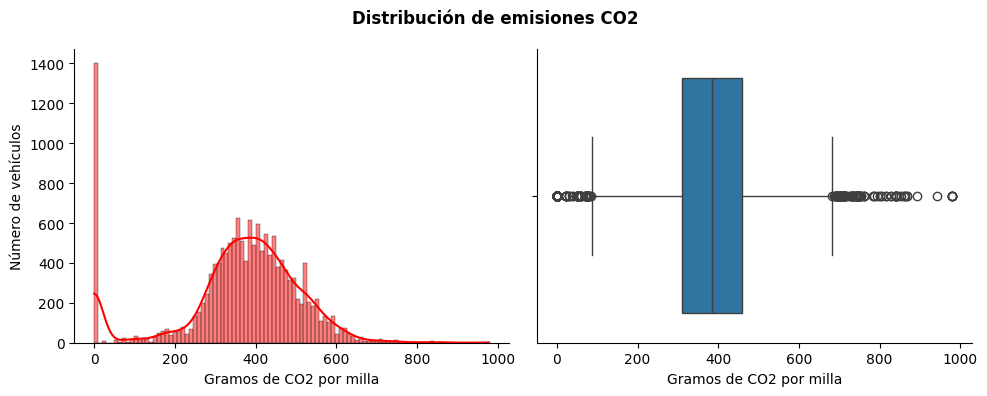

In [15]:
plot_distribucion(df, "CO2_Emissions_g_per_mile", "Gramos de CO2 por milla", titulo="Distribución de emisiones CO2", save_path="./img/emisiones_co2.png")

In [16]:
out_izq, out_der = calcular_outliers(df, "CO2_Emissions_g_per_mile")

=== CO2_Emissions_g_per_mile ===
Q1: 310.0 | Q3: 459.0 | IQR: 149.0
Límite inferior: 86.5 | Límite superior: 682.5
Outliers izquierda: 1456
Outliers derecha:   109


En el histogramas + KDE observamos:
- Un pico enorme cerca del 0 (son todos los vehículos eléctricos e hibridos que no emiten CO2)
- Una campana principal entre 300 y 500g/milla (aquí estarían la mayoría de los vehículos de combustión)
-  Una cola larga hacia la derecha ( correspondiente a los vehículos más contaminantes)

Diagrama de caja:
- Muestra una caja simétrica en torno a la mediana, lo que indica homogeneidad en el grupo central.

- Sin embargo, presenta outliers en ambos extremos: 

**Outliers izquierda (0 g/milla):** 

corresponden a los vehículos eléctricos e híbridos que no generan emisiones directas. No son errores sino una característica inherente a su tecnología.

**Outliers derecha (>600 g/milla):** 

corresponden a vehículos de combustión de alta cilindrada, SUVs de gran tamaño, camiones y vehículos de alto rendimiento con motores de 8 o más cilindros que superan ampliamente la media del mercado.

**Decisión: se mantienen.** 

Ambos extremos representan datos reales y válidos que reflejan la diversidad tecnológica del mercado. Eliminarlos ocultaría precisamente la brecha medioambiental entre EV e ICE que es el eje central de este análisis.


### 📌 Conclusión

El histograma junto con el diagrama de caja y la curva de densidad KDE revelan que la distribución de las emisiones de CO₂ presenta una forma bimodal con sesgo positivo. 

Se identifican dos modas claramente diferenciadas: una primera en torno a 0 g/milla, correspondiente a los vehículos eléctricos e híbridos que no generan emisiones directas, 

y una segunda moda principal alrededor de 380–400 g/milla, donde se concentra la gran mayoría de vehículos de combustión interna. 

La cola derecha de la distribución se extiende hasta valores cercanos a 1.000 g/milla, evidenciando la presencia de vehículos con emisiones extremadamente elevadas 

que arrastran la media por encima de la mediana, confirmando la asimetría positiva de la distribución. 

Este comportamiento bimodal indica que la variable CO₂ no sigue una distribución normal y que mezcla dos categorías de naturaleza muy distinta, 

lo que nos indica que la variable 'CO2_Emissions_g_per_mile' está estrechamente relacionada con 'Vehicle_Category' (lo cual comprobaremos en un posterior análisis de la 2 variables)."

<br><br>
* * ##### EV_Range_miles

Como la variable 'EV_Range_miles' solo tiene valores en los vehículos eléctricos, para ver su distribución de valores vamos primero a filtrar por vehículo EV(eléctricos)

In [17]:
ev = df[df["Vehicle_Category"] == "EV"]

In [18]:
ev.EV_Range_miles.describe()

count    1361.000000
mean      278.251286
std        70.339158
min        57.000000
25%       241.000000
50%       281.000000
75%       314.000000
max       520.000000
Name: EV_Range_miles, dtype: float64

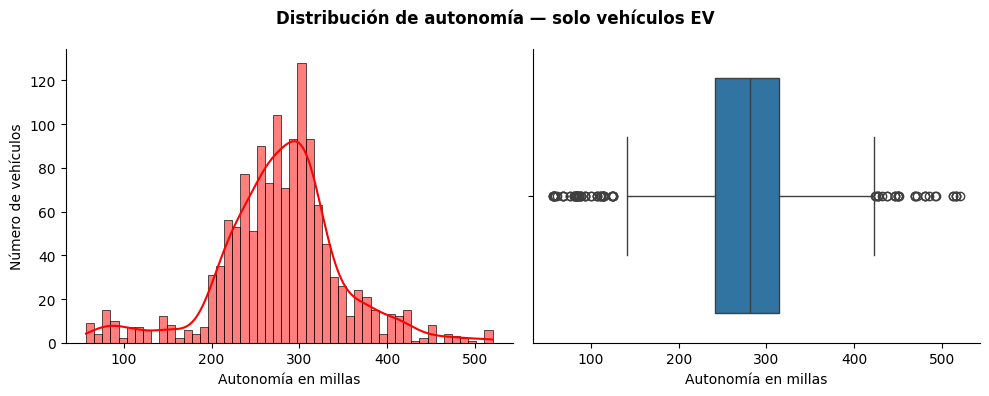

In [19]:
plot_distribucion(ev, "EV_Range_miles", "Autonomía en millas", bins=50, titulo="Distribución de autonomía — solo vehículos EV", save_path="./img/autonomia_ev.png")

In [20]:
out_izq, out_der = calcular_outliers(ev, "EV_Range_miles")

=== EV_Range_miles ===
Q1: 241.0 | Q3: 314.0 | IQR: 73.0
Límite inferior: 131.5 | Límite superior: 423.5
Outliers izquierda: 60
Outliers derecha:   32


En el histogramas + KDE observamos:
- Una distribución unimodal con colas en ambos extremos (leptocúrtica).
- La moda está en 300 millas, muy cerca de la media (278) y la mediana (281)
- Una pequeña pero visible cola a la izquierda ( correspondiente a los vehículos EV urbanos o de primera generación)
- Una cola más pequeña a la derecha (correspondiente a los vehículos EV premium)

Diagrama de caja:
- Muestra una caja aproximadamente simétrica: la mediana está centrada dentro de la caja

- Sin embargo también observamos outlier tanto a la izquierda como a la derecha de la caja, siendo más numerosos a la izquierda:

**Outliers izquierda (<131 millas — 60 modelos):** 

corresponden a vehículos eléctricos urbanos de primera generación con baterías de pequeña capacidad, como el smart fortwo (57 millas), el Mitsubishi i-MiEV (59 millas), el Fiat 500e (84 millas) 

o el BMW i3 (81 millas). Son modelos reales diseñados para uso urbano con autonomía limitada.

**Outliers derecha (>423 millas — 32 modelos):** 

corresponden a vehículos eléctricos de gama alta con baterías de gran capacidad, encabezados por el Lucid Air Dream R AWD (520 millas) y distintas versiones del Tesla Model S (hasta 405 millas).

**Decisión: se mantienen.** 

Los outliers de ambos extremos reflejan la evolución tecnológica del mercado EV — desde los primeros modelos urbanos de autonomía limitada hasta los vehículos premium de largo alcance actuales. 

Eliminarlos reduciría artificialmente la variabilidad real del mercado eléctrico y ocultaría información valiosa sobre su desarrollo histórico.

### 📌 Conclusión

La autonomía media de los vehículos eléctricos se sitúa en 278 millas (~447 km), con la mayoría de modelos estandarizados en el rango 241–314 millas. 

La presencia de outliers en ambos extremos refleja la convivencia de tres generaciones tecnológicas dentro del mercado EV: 

los modelos urbanos de primera generación con baterías pequeñas, la gama media actual que domina el mercado, 

y los vehículos premium de largo alcance que empujan el límite superior de la autonomía.

<br><br>
* * ##### Combined_MPG

In [21]:
df["Combined_MPG"].describe()

count    15300.00000
mean        29.74817
std         21.70054
min          9.00000
25%         19.00000
50%         23.00000
75%         28.00000
max        146.00000
Name: Combined_MPG, dtype: float64

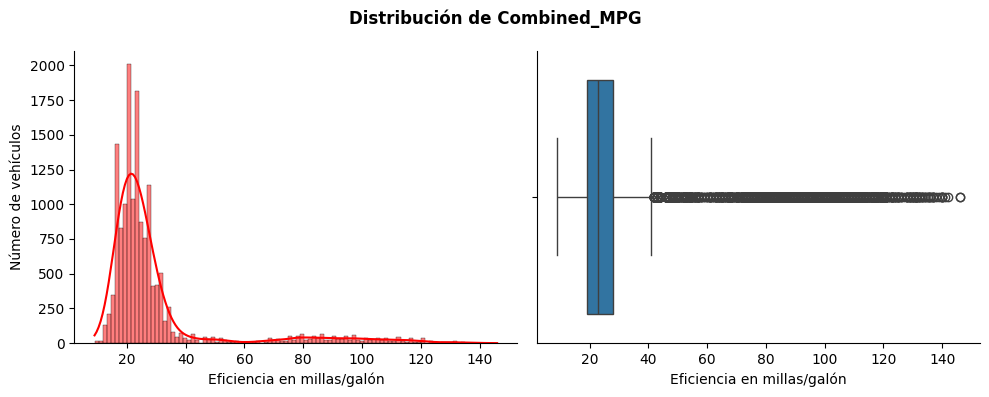

In [22]:
plot_distribucion(df, "Combined_MPG", "Eficiencia en millas/galón", save_path="./img/eficiencia_combinada")

In [23]:
out_izq, out_der = calcular_outliers(df, "Combined_MPG")

=== Combined_MPG ===
Q1: 19.0 | Q3: 28.0 | IQR: 9.0
Límite inferior: 5.5 | Límite superior: 41.5
Outliers izquierda: 0
Outliers derecha:   1677


En el histogramas + KDE observamos:
- Una distribución bimodal con sesgo positivo muy marcado.
- Una joroba principal muy pronuciada entre 15 y 30 MPG dondes se concentra los vehiculos ICE(de combustión)
- Una cola larguísima hacia la derecha que se extiende hasta más de 140 MPG, formada por los EV y alguno híbridos muy eficientes.
- El pico del grup ICE es muy alto y estrecho porque están muy concentrados, mientras que los EV se dispersan más hacia la derecha

Diagrama de caja:
- La caja está muy desplaza a la izquierda: la mediana (23) queda muy lejos de la media (29,75), poreque los EV con valores altísimos arrastran la media hacia la derecha (sesgo positivo fuerte)

- **Sin outliers a la izquierda.**

- **Outliers derecha (>41.5 MPG — 1.677 modelos):** 

corresponden en su totalidad a vehículos eléctricos e híbridos cuya eficiencia energética expresada en MPGe supera ampliamente la del grupo mayoritario ICE. 

El valor máximo es de 146 MPGe, registrado por el Lucid Air.

El elevado número de outliers (1.677) no indica errores en los datos sino la consecuencia directa de mezclar dos tecnologías radicalmente distintas en la misma variable — los ICE concentrados 

entre 9 y 41 MPG y los EV dispersos entre 42 y 146 MPGe.

**Decisión: se mantienen.**

Estos outliers son la evidencia más clara de la superioridad energética de los vehículos eléctricos frente a los de combustión. Eliminarlos equivaldría a eliminar todos los EV del análisis de eficiencia, 

lo que contradice el objetivo central del proyecto.

### 📌 Conclusión

La distribución de la eficiencia energética combinada presenta una forma bimodal con un sesgo positivo muy pronunciado, el más elevado de todas las variables analizadas. 

La distribución está dominada por los vehículos ICE, concentrados entre 15 y 30 MPG con moda en 21 MPG, lo que explica la mediana de 23 MPG. 

sin embargo, la presencia de vehículos eléctricos con valores de hasta 146 MPGe arrastra la media hasta 29.75 MPGe, evidenciando una gran diferencia entre ambos estadísticos. 

El boxplot no presenta outliers a la izquierda pero identifica más de 1500 outliers a la derecha, 

correspondientes en su mayoría a vehículos eléctricos e híbridos cuya eficiencia supera ampliamente la del grupo mayoritario ICE. 

Tenemos una distribución leptocúrtica con un pico muy pronunciado y colas especialmente pesadas, consecuencia directa de mezclar dos poblaciones tecnológicamente muy distintas en la misma variable.


<br><br>
* #### 6.3 - Análisis bivariante

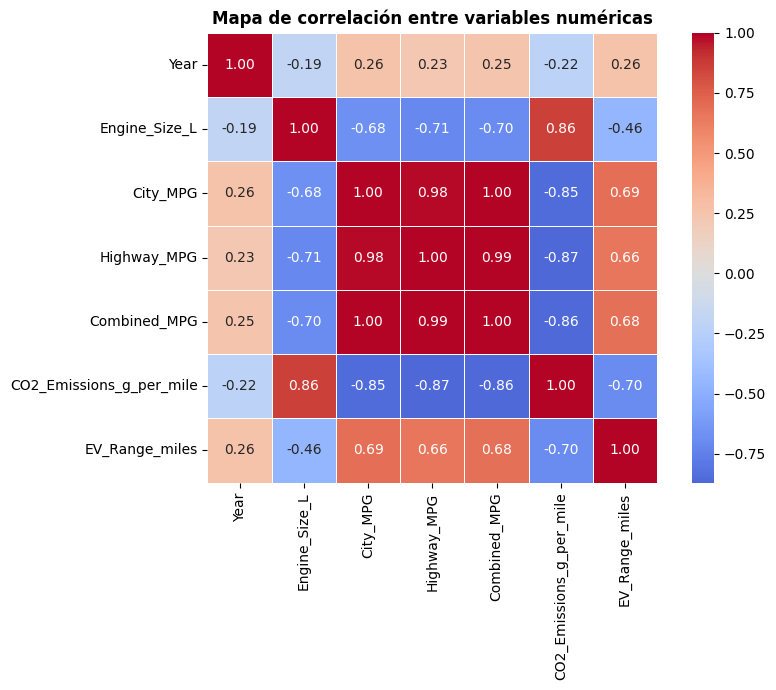

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    df.corr(numeric_only=True).round(2),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Mapa de correlación entre variables numéricas", fontweight="bold")
plt.tight_layout()
plt.savefig("../src/img/mapa_correlacion.png")
plt.show()

In [25]:
for var in ['CO2_Emissions_g_per_mile', 'Combined_MPG', 'EV_Range_miles']:
    resumen_por_categoria(df, var)

=== Resumen de CO2_Emissions_g_per_mile por Vehicle_Category ===

                   media  mediana  minimo  maximo     std
Vehicle_Category                                         
CNG               218.00    218.0     218     218     NaN
EV                  0.00      0.0       0       0    0.00
Hybrid/Other        0.00      0.0       0       0    0.00
ICE (Diesel)      406.22    425.0     272     525   60.54
ICE (Gas)         400.74    395.0      22     979  107.13
=== Resumen de Combined_MPG por Vehicle_Category ===

                  media  mediana  minimo  maximo    std
Vehicle_Category                                       
CNG               31.00     31.0      31      31    NaN
EV                93.84     92.0      47     146  17.92
Hybrid/Other      64.12     65.0      50      74   6.93
ICE (Diesel)      25.69     24.0      19      37   4.53
ICE (Gas)         23.32     22.0       9      59   6.38
=== Resumen de EV_Range_miles por Vehicle_Category ===

                   media  

c:\Users\user\Desktop\EDA\utils.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = df.groupby(categoria_col)[variable].agg(
c:\Users\user\Desktop\EDA\utils.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = df.groupby(categoria_col)[variable].agg(
c:\Users\user\Desktop\EDA\utils.py:213: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen = df.groupby(categoria_col)[variable].agg(



### 📌 Conclusión
El mapa de correlación confirma las relaciones esperadas entre las variables del dataset. 

La correlación más fuerte es la negativa entre CO₂ y Combined_MPG (−0.70), lo que confirma que a mayor eficiencia energética menores son las emisiones directas. 

EV_Range_miles correlaciona negativamente con CO₂ (−0.70) y positivamente con Combined_MPG (+0.68), reflejando que los vehículos eléctricos de mayor autonomía son también los más eficientes. 

La correlación positiva entre Year y EV_Range_miles (+0.26) confirma la tendencia de mejora de autonomía con el tiempo que analizaremos en detalle más adelante.

<br><br>
* #### 6.4 - Test estadístico

En el análisis univariante ya observamos que las variables presentan distribuciones bimodales, con sesgo y outliers, 

por lo que no siguen una distribución normal ni tienen varianzas homogéneas entre grupos.

Por este motivo aplicamos el **test de Mann-Whitney U**, alternativa no paramétrica que permite comparar dos grupos independientes sin asumir normalidad ni homocedasticidad.

In [26]:
from scipy import stats

ev     = df[df["Vehicle_Category"] == "EV"]
ice    = df[df["Vehicle_Category"] == "ICE (Gas)"]
diesel = df[df["Vehicle_Category"] == "ICE (Diesel)"]
hybrid = df[df["Vehicle_Category"] == "Hybrid/Other"]

comparaciones = [
    ("EV",           "ICE (Gas)",     ev,     ice),
    ("EV",           "ICE (Diesel)",  ev,     diesel),
    ("EV",           "Hybrid/Other",  ev,     hybrid),
    ("ICE (Gas)",    "ICE (Diesel)",  ice,    diesel),
    ("Hybrid/Other", "ICE (Gas)",     hybrid, ice),
]

variables = ['CO2_Emissions_g_per_mile', 'Combined_MPG', 'EV_Range_miles']

for var in variables:
    mann_whitney_categorias(df, var)

=== Mann-Whitney U — CO2_Emissions_g_per_mile ===

  ICE (Gas) vs ICE (Diesel):
    U=1942230 | p=0.030672 → Significativa ✅
  ICE (Gas) vs EV:
    U=18494629 | p=0.000000 → Significativa ✅
  ICE (Gas) vs CNG:
    U=13050 | p=0.110843 → No significativa ❌
  ICE (Gas) vs Hybrid/Other:
    U=557149 | p=0.000000 → Significativa ✅
  ICE (Diesel) vs EV:
    U=419188 | p=0.000000 → Significativa ✅
  ICE (Diesel) vs CNG:
    U=308 | p=0.085151 → No significativa ❌
  ICE (Diesel) vs Hybrid/Other:
    U=12628 | p=0.000000 → Significativa ✅
  EV vs CNG:
    U=0 | p=0.000000 → Significativa ✅
  EV vs Hybrid/Other:
    U=27900 | p=1.000000 → No significativa ❌
  CNG vs Hybrid/Other:
    U=41 | p=0.000000 → Significativa ✅

=== Mann-Whitney U — Combined_MPG ===

  ICE (Gas) vs ICE (Diesel):
    U=1459950 | p=0.000000 → Significativa ✅
  ICE (Gas) vs EV:
    U=1900 | p=0.000000 → Significativa ✅
  ICE (Gas) vs CNG:
    U=1268 | p=0.158282 → No significativa ❌
  ICE (Gas) vs Hybrid/Other:
    U=340 |

### 📌 Conclusión

El test confirma que las diferencias observadas entre categorías de vehículo no son fruto del azar sino estadísticamente significativas (p < 0.05) en prácticamente todas las comparaciones.

La única excepción es **EV vs Hybrid/Other en CO₂ (p = 1.000)**, ambas categorías registran exactamente 0 g/milla de emisiones directas, por lo que el test no puede distinguirlas en esta variable. 

Sin embargo sí son significativamente distintas en eficiencia (Combined_MPG) y autonomía (EV_Range_miles).

| Comparación | CO₂ | MPG | Autonomía |
|---|---|---|---|
| EV vs ICE (Gas) | ✅ | ✅ | ✅ |
| EV vs ICE (Diesel) | ✅ | ✅ | ✅ |
| **EV vs Hybrid/Other** | **❌ p=1.000** | ✅ | ✅ |
| ICE (Gas) vs ICE (Diesel) | ✅ | ✅ | ✅ |
| Hybrid vs ICE (Gas) | ✅ | ✅ | ✅ |

<br><br>
El mapa de correlación evidencia cómo se relacionan las variables entre sí, mientras que el test de Mann-Whitney U confirma que las diferencias entre tipos de vehículo son reales y no casuales. 

Ambos análisis apuntan en la misma dirección: los vehículos eléctricos constituyen una categoría estadísticamente diferenciada del resto, tanto en eficiencia energética como en emisiones de CO₂.



<br><br>
* #### 6.5 - Análisis bivariante y multivariante necesario para la contestación de las preguntas planteadas

* * ##### **¿HA CRECIDO LA FABRICACIÓN DE VEHÍCULOS ELÉCTRICOS ENTRE 2015 Y 2026?**

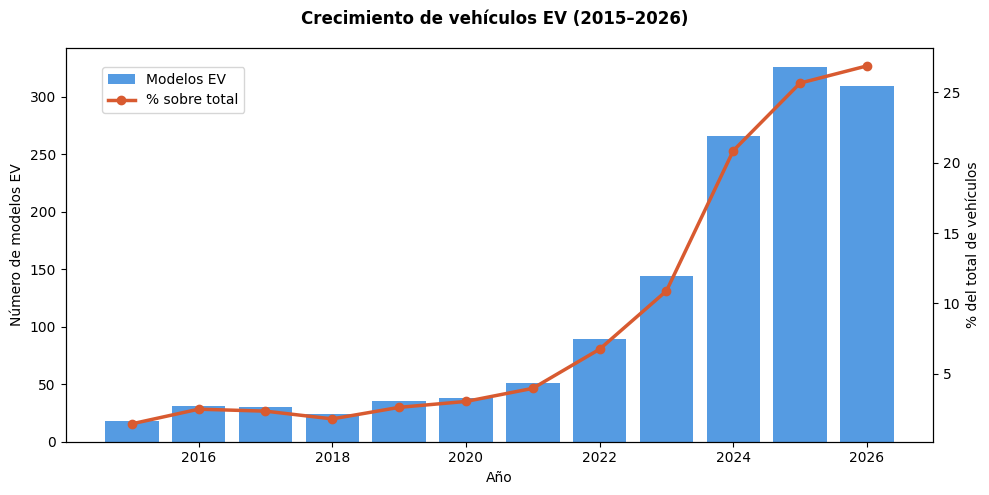

In [ ]:
# Modelos EV por año
ev_por_año = df[df["Vehicle_Category"] == "EV"].groupby("Year").size().reset_index(name="modelos_EV")

# Total de vehiculos por año
total_por_año = df.groupby("Year").size().reset_index(name="total")

# Unir y calcular porcentaje
resumen = ev_por_año.merge(total_por_año, on="Year")
resumen["%_EV"] = (resumen["modelos_EV"] / resumen["total"] * 100).round(2)

# Gráfica
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(resumen.Year, resumen.modelos_EV, color="#378ADD", alpha=0.85, label="Modelos EV")
ax1.set_ylabel("Número de modelos EV")
ax1.set_xlabel("Año")

ax2 = ax1.twinx()
ax2.plot(resumen.Year, resumen["%_EV"], color="#D85A30", marker="o", linewidth=2.5, label="% sobre total")
ax2.set_ylabel("% del total de vehículos")

fig.suptitle("Crecimiento de vehículos EV (2015–2026)", fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig("../src/img/crecimiento_ev.png", bbox_inches="tight")
plt.show()

In [28]:
# Modelos EV por año y porcentaje sobre el total
resumen["crecimiento_%"] = resumen["modelos_EV"].pct_change().mul(100).round(1)

print(resumen)

    Year  modelos_EV  total   %_EV  crecimiento_%
0   2015          18   1241   1.45            NaN
1   2016          31   1243   2.49           72.2
2   2017          30   1274   2.35           -3.2
3   2018          24   1331   1.80          -20.0
4   2019          35   1335   2.62           45.8
5   2020          38   1252   3.04            8.6
6   2021          51   1286   3.97           34.2
7   2022          89   1319   6.75           74.5
8   2023         144   1322  10.89           61.8
9   2024         266   1276  20.85           84.7
10  2025         326   1271  25.65           22.6
11  2026         309   1150  26.87           -5.2


In [29]:
# "Crecimiento relativo del 1711% en 10 años"
ev_2015 = resumen[resumen["Year"] == 2015]["modelos_EV"].values[0]
ev_2025 = resumen[resumen["Year"] == 2025]["modelos_EV"].values[0]

crecimiento_absoluto = ev_2025 - ev_2015
crecimiento_relativo = ((ev_2025 / ev_2015) - 1) * 100

print(f"Crecimiento absoluto: +{crecimiento_absoluto} modelos")
print(f"Crecimiento relativo: +{crecimiento_relativo:.0f}%")

Crecimiento absoluto: +308 modelos
Crecimiento relativo: +1711%


In [30]:
primer_ev = ev.groupby("Make")["Year"].min().reset_index()
primer_ev.columns = ["Marca", "Primer_año_EV"]
primer_ev = primer_ev.dropna(subset=["Primer_año_EV"])
primer_ev = primer_ev.sort_values("Primer_año_EV")

primer_ev

C:\Users\user\AppData\Local\Temp\ipykernel_8744\1233153851.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  primer_ev = ev.groupby("Make")["Year"].min().reset_index()


,Marca,Primer_año_EV
4,BMW,2015.0
11,Chevrolet,2015.0
17,Ford,2015.0
15,Fiat,2015.0
41,Mercedes-Benz,2015.0
45,Nissan,2015.0
28,Kia,2015.0
57,Tesla,2015.0
60,Volkswagen,2015.0
62,smart,2015.0


### 📌 Conclusión

Los datos confirman un crecimiento sostenido y acelerado de los vehículos eléctricos a lo largo del período analizado. 

En 2015 solo se registraban 18 modelos EV, representando el 1.45% del total de vehículos del dataset. 

En 2025 esa cifra alcanzó los 326 modelos, lo que supone el 25.65% del total, un crecimiento relativo del 1711% en 10 años.

El análisis año a año revela que el crecimiento no fue lineal sino que presenta un claro punto de inflexión a partir de 2022, donde los modelos EV empezaron a crecer de forma exponencial: 

de 51 modelos en 2021 se pasó a 89 en 2022 (+74.5%), 144 en 2023 (+61.8%), 266 en 2024 (+84.7%) y 326 en 2025 (+22.6%). 

Este despegue coincide con la entrada masiva de fabricantes tradicionales como BMW, Hyundai, Audi y Mercedes-Benz al mercado eléctrico.

En 2025 y 2026 la tendencia apunta a que 1 de cada 4 vehículos del mercado será eléctrico, consolidando una transformación estructural del sector del automóvil.

<br><br>
* * ##### **¿CUÁNTO CO2 EMITE UN ICE vs UN EV EN PROMEDIO?**

In [31]:
cats = ['ICE (Gas)', 'ICE (Diesel)', 'Hybrid/Other', 'EV']
df_cats = df[df["Vehicle_Category"].isin(cats)]

resumen_co2 = df_cats.groupby("Vehicle_Category")["CO2_Emissions_g_per_mile"].agg(
    media="mean",
    mediana="median",
    minimo="min",
    maximo="max"
).round(1)

print(resumen_co2)

                  media  mediana  minimo  maximo
Vehicle_Category                                
CNG                 NaN      NaN     NaN     NaN
EV                  0.0      0.0     0.0     0.0
Hybrid/Other        0.0      0.0     0.0     0.0
ICE (Diesel)      406.2    425.0   272.0   525.0
ICE (Gas)         400.7    395.0    22.0   979.0


C:\Users\user\AppData\Local\Temp\ipykernel_8744\1555598252.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_co2 = df_cats.groupby("Vehicle_Category")["CO2_Emissions_g_per_mile"].agg(


C:\Users\user\AppData\Local\Temp\ipykernel_8744\3923483530.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medias = df_cats.groupby("Vehicle_Category")["CO2_Emissions_g_per_mile"].mean().round(1)


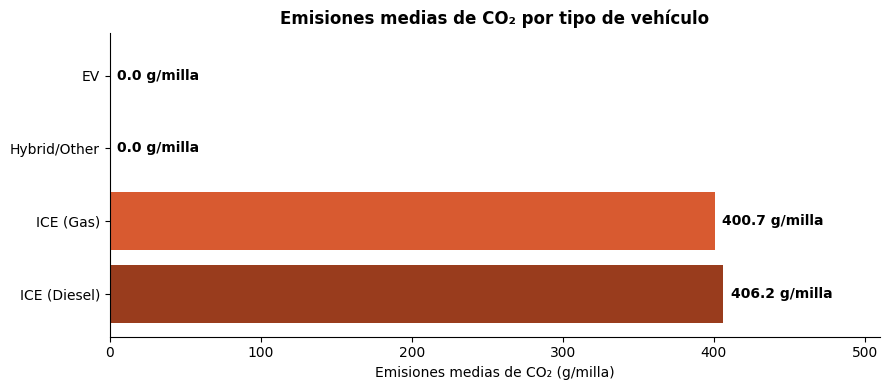

In [ ]:
cats = ['ICE (Diesel)', 'ICE (Gas)', 'Hybrid/Other', 'EV']
df_cats = df[df["Vehicle_Category"].isin(cats)]

medias = df_cats.groupby("Vehicle_Category")["CO2_Emissions_g_per_mile"].mean().round(1)
medias = medias.reindex(cats)

colores = ['#993C1D', '#D85A30', '#1D9E75', '#378ADD']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(medias.index, medias.values, color=colores)

for bar, val in zip(bars, medias.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2,
            f'{val} g/milla', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel("Emisiones medias de CO₂ (g/milla)")
ax.set_title("Emisiones medias de CO₂ por tipo de vehículo", fontweight='bold')
ax.set_xlim(0, 510)
sns.despine()
plt.tight_layout()
plt.savefig("../src/img/emisiones_co2_vehiculo", bbox_inches="tight")
plt.show()



### 📌 Conclusión

Los datos muestran una diferencia radical en las emisiones directas de CO₂ entre los vehículos de combustión y los eléctricos. 

Los vehículos ICE de gasolina emiten una media de 400.7 g/milla (249 g/km), mientras que los de diésel alcanzan los 406.2 g/milla (252.5 g/km). 

En cambio, los vehículos eléctricos e híbridos registran 0 g/milla de emisiones directas, lo que supone una reducción del 100% respecto a los ICE.

Es importante matizar que las emisiones de los EV no son cero en términos absolutos, dependen de la fuente de energía eléctrica utilizada para cargar la batería, que varía según el país y su mix energético. 

Sin embargo, en términos de emisiones directas en el punto de uso, la diferencia es total.

<br><br>
* * ##### **¿HA MEJORADO LA AUTONOMÍA DE LOS EV CON LOS AÑOS?**

In [33]:
resumen_range = ev.groupby("Year")["EV_Range_miles"].agg(
    media="mean",
    mediana="median",
    minimo="min",
    maximo="max"
).round(1).reset_index()

resumen_range["media_km"] = (resumen_range["media"] * 1.609).round(1)
resumen_range["crecimiento_%"] = resumen_range["media"].pct_change().mul(100).round(1)

print(resumen_range)

    Year  media  mediana  minimo  maximo  media_km  crecimiento_%
0   2015  157.4     90.0      68     270     253.3            NaN
1   2016  185.1    218.0      62     315     297.8           17.6
2   2017  186.9    205.0      57     335     300.7            1.0
3   2018  197.1    212.5      57     335     317.1            5.5
4   2019  229.2    239.0      57     370     368.8           16.3
5   2020  260.3    258.5     110     402     418.8           13.6
6   2021  246.9    239.0      59     405     397.3           -5.1
7   2022  274.8    258.0     100     520     442.2           11.3
8   2023  276.4    270.0     100     516     444.7            0.6
9   2024  286.8    282.5     114     516     461.5            3.8
10  2025  292.0    289.0     141     512     469.8            1.8
11  2026  302.8    295.0     141     512     487.2            3.7


In [34]:
# Modelo con mayor autonomía cada año
idx_max = ev.groupby("Year")["EV_Range_miles"].idxmax()
top_autonomia = ev.loc[idx_max, ["Year","Make","Model","EV_Range_miles"]].sort_values("Year")
print(top_autonomia)

       Year   Make                                     Model  EV_Range_miles
1218   2015  Tesla                         Model S AWD - 85D             270
3316   2016  Tesla                       Model S AWD - P100D             315
3778   2017  Tesla                        Model S AWD - 100D             335
4957   2018  Tesla                              Model S 100D             335
6510   2019  Tesla                        Model S Long Range             370
7821   2020  Tesla                   Model S Long Range Plus             402
9095   2021  Tesla                        Model S Long Range             405
9531   2022  Lucid          Air Dream R AWD w/19 inch wheels             520
11326  2023  Lucid  Air G Touring XR AWD with 19 inch wheels             516
12847  2024  Lucid   Air G Touring XR AWD with19 inch wheels             516
13378  2025  Lucid  Air G Touring XR AWD with 19 inch wheels             512
14957  2026  Lucid   Air G Touring XR AWD with19 inch wheels             512

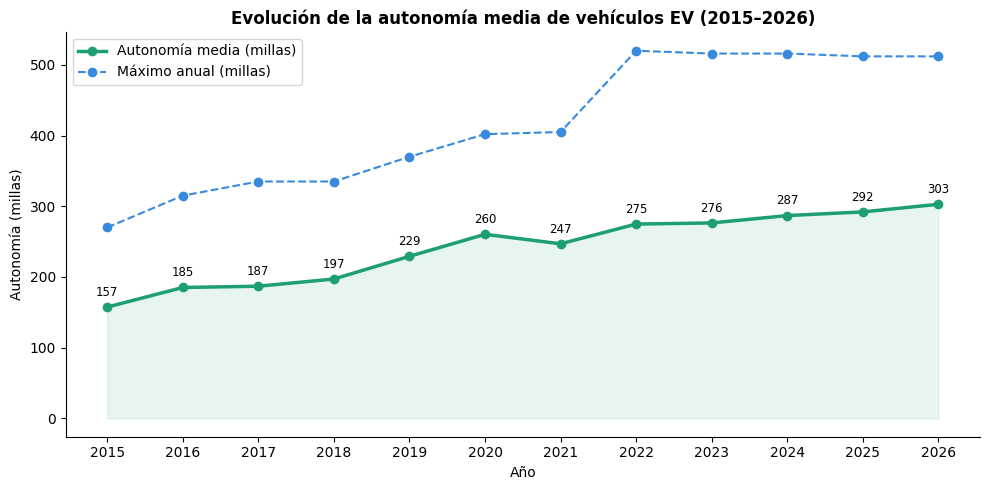

In [ ]:
resumen_range = ev.groupby("Year")["EV_Range_miles"].agg(
    media="mean",
    maximo="max"
).round(1).reset_index()

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))

# Línea media con área rellena
ax.fill_between(resumen_range.Year, resumen_range.media, alpha=0.1, color='#1D9E75')
ax.plot(resumen_range.Year, resumen_range.media, marker='o', color='#1D9E75',
        linewidth=2.5, label='Autonomía media (millas)')

# Línea máximo
ax.plot(resumen_range.Year, resumen_range.maximo, marker='o', color='#378ADD',
        linewidth=1.5, linestyle='--', label='Máximo anual (millas)')

# Etiquetas sobre la línea media
for _, row in resumen_range.iterrows():
    ax.annotate(f"{row.media:.0f}",
                (row.Year, row.media),
                textcoords='offset points',
                xytext=(0, 8),
                ha='center', fontsize=8.5)

ax.set_title('Evolución de la autonomía media de vehículos EV (2015–2026)', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Autonomía (millas)')
ax.set_xticks(resumen_range.Year)
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("../src/img/autonomía_EV.png", bbox_inches="tight")
plt.show()

In [36]:
resumen = ev.groupby("Year")["EV_Range_miles"].mean().round(1)

r2020 = resumen[2020]
r2021 = resumen[2021]

variacion = ((r2021 / r2020) - 1) * 100

print(f"Autonomía media 2020: {r2020} millas")
print(f"Autonomía media 2021: {r2021} millas")
print(f"Variación: {variacion:.1f}%")

Autonomía media 2020: 260.3 millas
Autonomía media 2021: 246.9 millas
Variación: -5.1%


In [37]:
resumen = ev.groupby("Year")["EV_Range_miles"].mean().round(1)

r2015 = resumen[2015]
r2025 = resumen[2025]

mejora_relativa(r2015, r2025, "Autonomía media EV 2015–2025", "millas")

=== Autonomía media EV 2015–2025 ===
Valor inicial:   157.4 millas
Valor final:     292.0 millas
Mejora absoluta: +134.6 millas
Mejora relativa: +85.5%


(np.float64(134.6), np.float64(85.5146124523507))

### 📌 Conclusión

Los datos confirman una mejora sostenida en la autonomía media de los vehículos eléctricos a lo largo del período analizado. 

En 2015 la autonomía media era de 157.4 millas (253 km), cifra que ascendió hasta las 292 millas (470 km) en 2025, 

lo que supone una mejora absoluta de 134.6 millas (+217 km) y una mejora relativa del 85.5% en 10 años.

El crecimiento no fue lineal, en 2021 se produjo un retroceso puntual del 5.1% respecto al año anterior, posiblemente relacionado con la entrada de nuevos modelos de gama baja que bajaron la media. 

Sin embargo la tendencia general es claramente ascendente.

En cuanto al modelo con mayor autonomía cada año, Tesla dominó el liderazgo desde 2015 hasta 2021, alcanzando las 405 millas con el Model S Long Range. 

A partir de 2022 Lucid tomó el relevo con su Air Dream R AWD, que estableció un nuevo récord de 520 millas (~837 km) con una sola carga, valor que se mantiene como máximo del dataset hasta 2026.

Esta evolución de la autonomía es clave desde el punto de vista medioambiental, ya que elimina progresivamente la principal barrera de adopción del vehículo eléctrico, el llamado 'range anxiety' o miedo a quedarse sin batería,

facilitando así la transición hacia una movilidad más sostenible.

<br><br>
* * ##### **¿QUÉ MARCAS FABRICAN MÁS VEHÍCULOS ELÉCTRICOS?**

In [38]:
total_marcas = ev["Make"].nunique()
print(f"Total fabricantes con al menos un EV: {total_marcas}")

Total fabricantes con al menos un EV: 39


In [39]:
por_marca = ev.groupby("Make").size().reset_index(name="modelos_EV")
por_marca["%_total"] = (por_marca["modelos_EV"] / por_marca["modelos_EV"].sum() * 100).round(1)
por_marca = por_marca.sort_values("modelos_EV", ascending=False)

print(f"\nTop 5 concentran: {por_marca.head(5)['%_total'].sum():.1f}% del total")
print(f"Top 10 concentran: {por_marca.head(10)['%_total'].sum():.1f}% del total")
por_marca.head(39)


Top 5 concentran: 46.2% del total
Top 10 concentran: 67.4% del total


C:\Users\user\AppData\Local\Temp\ipykernel_8744\2865462040.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  por_marca = ev.groupby("Make").size().reset_index(name="modelos_EV")


,Make,modelos_EV,%_total
57,Tesla,177,13.0
51,Rivian,161,11.8
4,BMW,131,9.6
48,Porsche,93,6.8
41,Mercedes-Benz,68,5.0
3,Audi,68,5.0
17,Ford,60,4.4
36,Lucid,57,4.2
21,Hyundai,53,3.9
45,Nissan,51,3.7


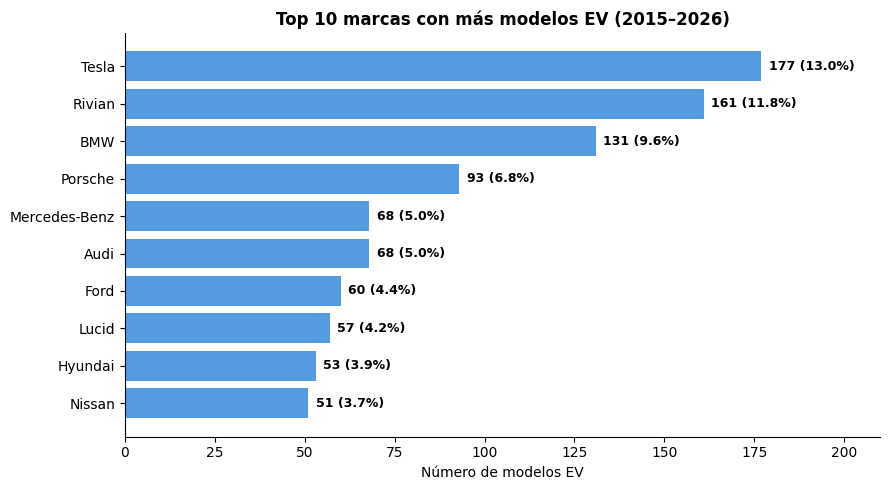

In [ ]:
top10 = por_marca.head(10)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(top10.Make[::-1], top10.modelos_EV[::-1], color='#378ADD', alpha=0.85)

for bar, val, pct in zip(bars, top10.modelos_EV[::-1], top10["%_total"][::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct}%)', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel("Número de modelos EV")
ax.set_title("Top 10 marcas con más modelos EV (2015–2026)", fontweight='bold')
ax.set_xlim(0, 210)
sns.despine()
plt.tight_layout()
plt.savefig("../src/img/top_10_marcas.png", bbox_inches="tight")
plt.show()

### 📌 Conclusión

El análisis por marca revela que 39 fabricantes distintos tienen al menos un modelo EV en el dataset, aunque la oferta está muy concentrada en unos pocos. 

Las cinco marcas con más modelos eléctricos — Tesla (177, 13%), Rivian (161, 11.8%), BMW (131, 9.6%), Porsche (93, 6.8%) y Mercedes-Benz (68, 5%) — acumulan el 46.2% del total de modelos EV. 

Si ampliamos al top 10, la concentración sube al 67.4%.

Destaca especialmente el caso de Rivian, que pese a haber entrado al mercado en 2022 — siete años después que Tesla — ya ocupa el segundo puesto en número de modelos, 

lo que refleja una apuesta muy agresiva por la electrificación desde su fundación.

Por otro lado, marcas con larga tradición como Toyota, Honda o Mazda presentan una oferta EV muy reducida (23, 12 y 2 modelos respectivamente), lo que evidencia estrategias más conservadoras 

o una mayor apuesta por los híbridos frente al eléctrico puro.

<br><br>
* * ##### **¿LOS VEHÍCULOS HÍBRIDOS SON REALMENTE MÁS EFICIENTES QUE LOS GASOLINA?**

El MPG (*miles per gallon*) mide cuántas millas recorre un vehículo con el equivalente a un galón de combustible. Para EVs se calcula en MPGe (equivalente eléctrico).

**Primero vamos a ver la eficicencia por categorías para luego centrarnos en Hibridos y Gasolina**

C:\Users\user\AppData\Local\Temp\ipykernel_8744\136655646.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eficiencia = df[df['Vehicle_Category'].isin(cats)].groupby('Vehicle_Category')['Combined_MPG'].mean().round(1)


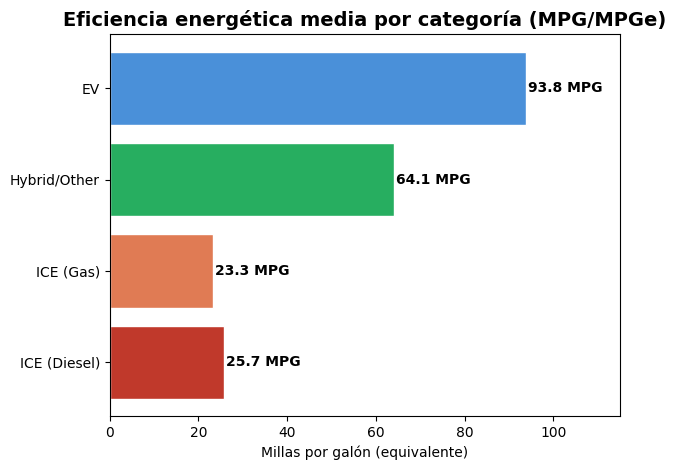


 Un EV es 4.0x más eficiente que un ICE de gasolina

 Un Hibrido es 2.8x más eficiente que un ICE de gasolina


In [ ]:
colores = {'ICE (Gas)': '#E07B54', 'EV': '#4A90D9', 
           'ICE (Diesel)': '#C0392B', 'Hybrid/Other': '#27AE60', 'CNG': '#8E44AD'}

eficiencia = df[df['Vehicle_Category'].isin(cats)].groupby('Vehicle_Category')['Combined_MPG'].mean().round(1)
eficiencia = eficiencia.reindex(cats)

fig, ax = plt.subplots()
bars = ax.barh(eficiencia.index, eficiencia.values, color=[colores[c] for c in eficiencia.index], edgecolor='white')

for bar, val in zip(bars, eficiencia.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val} MPG', va='center', fontweight='bold')

ax.set_title('Eficiencia energética media por categoría (MPG/MPGe)', fontsize=14, fontweight='bold')
ax.set_xlabel('Millas por galón (equivalente)')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig("../src/img/eficiencia_energetica_cat.png", bbox_inches="tight")
plt.show()

print(f'\n Un EV es {eficiencia["EV"]/eficiencia["ICE (Gas)"]:.1f}x más eficiente que un ICE de gasolina')
print(f'\n Un Hibrido es {eficiencia["Hybrid/Other"]/eficiencia["ICE (Gas)"]:.1f}x más eficiente que un ICE de gasolina')

**Ahora vamos a centrarnos en los datos de Hibridos y Gasolina para responder a la pregunta planteada**

In [44]:
cats = ['ICE (Gas)', 'Hybrid/Other']
df_comp = df[df["Vehicle_Category"].isin(cats)]

In [45]:
# Eficiencia por tipo
resumen_mpg = df_comp.groupby("Vehicle_Category")[["City_MPG","Highway_MPG","Combined_MPG"]].mean().round(1)

resumen_mpg = resumen_mpg.dropna()
resumen_mpg.T

C:\Users\user\AppData\Local\Temp\ipykernel_8744\1781275274.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_mpg = df_comp.groupby("Vehicle_Category")[["City_MPG","Highway_MPG","Combined_MPG"]].mean().round(1)


Vehicle_Category,Hybrid/Other,ICE (Gas)
City_MPG,65.9,20.9
Highway_MPG,62.2,27.4
Combined_MPG,64.1,23.3


In [46]:
# Mejora relativa
hybrid_mpg = resumen_mpg.loc["Hybrid/Other", "Combined_MPG"]
ice_mpg    = resumen_mpg.loc["ICE (Gas)", "Combined_MPG"]
mejora     = ((hybrid_mpg / ice_mpg) - 1) * 100

print(f"\nMejora eficiencia híbrido vs ICE: +{mejora:.1f}%")


Mejora eficiencia híbrido vs ICE: +175.1%


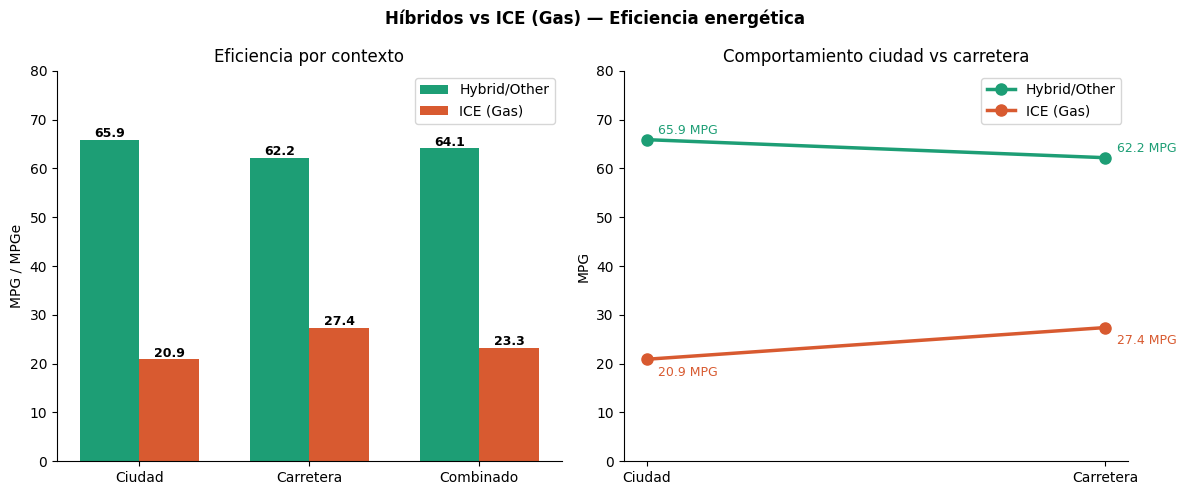

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Híbridos vs ICE (Gas) — Eficiencia energética", fontweight='bold')

# ── Gráfico 1: barras agrupadas ──────────────────────────────
categorias = ["Ciudad", "Carretera", "Combinado"]
x = np.arange(len(categorias))
ancho = 0.35

hybrid_vals = resumen_mpg.loc["Hybrid/Other"].values
ice_vals    = resumen_mpg.loc["ICE (Gas)"].values

bars1 = axs[0].bar(x - ancho/2, hybrid_vals, ancho, label="Hybrid/Other", color="#1D9E75")
bars2 = axs[0].bar(x + ancho/2, ice_vals,    ancho, label="ICE (Gas)", color="#D85A30")

# Etiquetas encima de cada barra
for bar in bars1:
    axs[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    axs[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

axs[0].set_xticks(x)
axs[0].set_xticklabels(categorias)
axs[0].set_ylabel("MPG / MPGe")
axs[0].set_title("Eficiencia por contexto")
axs[0].set_ylim(0, 80)
axs[0].legend()

# ── Gráfico 2: líneas ciudad vs carretera ────────────────────
contextos = ["Ciudad", "Carretera"]

axs[1].plot(contextos, [65.9, 62.2], marker='o', color='#1D9E75',
            linewidth=2.5, markersize=8, label="Hybrid/Other")
axs[1].plot(contextos, [20.9, 27.4], marker='o', color='#D85A30',
            linewidth=2.5, markersize=8, label="ICE (Gas)")

# Etiquetas en cada punto
for y, label in zip([65.9, 62.2], ["65.9", "62.2"]):
    axs[1].annotate(f'{label} MPG', xy=('Ciudad' if y==65.9 else 'Carretera', y),
                    textcoords='offset points', xytext=(8, 4), fontsize=9, color='#1D9E75')
for y, label in zip([20.9, 27.4], ["20.9", "27.4"]):
    axs[1].annotate(f'{label} MPG', xy=('Ciudad' if y==20.9 else 'Carretera', y),
                    textcoords='offset points', xytext=(8, -12), fontsize=9, color='#D85A30')

axs[1].set_ylabel("MPG")
axs[1].set_title("Comportamiento ciudad vs carretera")
axs[1].set_ylim(0, 80)
axs[1].legend()

sns.despine()
plt.tight_layout()
plt.savefig("../src/img/eficiencia_energetica_hibr_vs_gas.png", bbox_inches="tight")
plt.show()

### 📌 Conclusión

Los datos confirman que los vehículos híbridos son significativamente más eficientes que los de gasolina. 

Con una eficiencia combinada media de 64.1 MPG frente a los 23.3 MPG de los ICE de gasolina, los híbridos superan en un 175% la eficiencia energética de los vehículos de combustión convencionales.

Especialmente llamativo es el comportamiento en ciudad: mientras que los ICE son más eficientes en carretera que en ciudad (27.4 vs 20.9 MPG), 

los híbridos invierten este patrón siendo más eficientes en ciudad que en carretera (65.9 vs 62.2 MPG). 

Esto se explica por el frenado regenerativo — tecnología que convierte la energía del frenado en electricidad — que aprovecha especialmente bien las condiciones de conducción urbana con frecuentes arranques y frenadas.

En conclusión los híbridos son claramente más eficientes que los vehículos de gasolina, tanto en consumo como en emisiones directas.

<br><br>
## 📝  **Conclusiones finales del EDA**

- **1.- Un mercado dominado por el ICE pero en transformación**

    El dataset refleja un mercado todavía dominado por los vehículos de combustión, el 88.8% de los modelos son ICE de gasolina frente al 8.9% de EV. 

    Sin embargo, los datos revelan una transformación estructural acelerada: en 2015 los EV representaban apenas el 1.5% del total, 

    cifra que en 2025 alcanzó el 25.65%, con un crecimiento relativo del 1711% en diez años.<br><br><br>

- **2. El impacto ambiental es radical**

    La diferencia en emisiones directas de CO₂ entre ICE y EV es absoluta. Los vehículos de gasolina emiten una media de 400.7 g/milla (249 g/km) y los diésel 406.2 g/milla (252.5 g/km),

    mientras que los eléctricos registran 0 g/milla de emisiones directas. Cabe matizar que las emisiones indirectas de los EV dependen del mix energético del país donde se carguen.<br><br><br>   

- **3. La autonomía casi se ha duplicado**

    Uno de los principales frenos para la adopción del EV, el llamado 'range anxiety' (miedo a quedarse sin batería), se ha reducido significativamente. 

    La autonomía media pasó de 157.4 millas (253 km) en 2015 a 292 millas (470 km) en 2025, una mejora del 85.5%. 

    El récord lo ostenta el Lucid Air con 520 millas (837 km), desbancando a Tesla en 2022.<br><br><br>

- **4. Los EV son 4 veces más eficientes que los ICE**

    En términos de eficiencia energética, los EV alcanzan una media de 93.8 MPG frente a los 23.3 MPG de los ICE de gasolina, lo que supone una eficiencia 4 veces superior. 

    Los híbridos ocupan una posición intermedia con 64.1 MPG, y destacan por ser más eficientes en ciudad (65.9 MPG) que en carretera (62.2 MPG) gracias al frenado regenerativo, al contrario que los ICE.<br><br><br>

- **5. La industria apuesta masivamente por el EV**

    39 fabricantes distintos tienen al menos un modelo EV en el dataset. Tesla y Rivian lideran en número de modelos (177 y 161 respectivamente),

    seguidos de fabricantes tradicionales como BMW (131), Porsche (93) y Mercedes-Benz (68). 

    La tercera oleada de entrada al mercado EV, protagonizada por Toyota, Jeep, Dodge o Rolls-Royce entre 2022 y 2024, es la que explica el punto de inflexión en el crecimiento observado a partir de ese año.<br><br><br><br>

   ### - **Conclusión general** 

   Los datos analizados confirman que el sector del automóvil está viviendo una transición tecnológica sin precedentes hacia la electrificación. 
   
   Los vehículos eléctricos superan ampliamente a los de combustión en eficiencia energética y emisiones directas, y su presencia en el mercado crece de forma acelerada especialmente a partir de 2022.
   
   Según los datos del dataset, los EV ya superaron el 25% de la oferta total en 2025 (25.65%), alcanzando el 26.87% en 2026, consolidando un cambio estructural con importantes implicaciones medioambientales.
   
   

### 🏆 Hallazgos Clave

| Hallazgo | Valor | Detalle |
|---|---|---|
| 📈 Crecimiento EV | **+1711%** | De 18 modelos en 2015 a 326 en 2025 |
| 🌍 Reducción emisiones directas | **−100%** | EV: 0 g/milla vs ICE: 400.7 g/milla |
| 🔋 Mejora autonomía media | **+85.5%** | De 157 millas (2015) a 292 millas (2025) |
| ⚡ Eficiencia EV vs ICE | **×4 veces** | 93.8 MPGe vs 23.3 MPG |
| 🚗 Eficiencia híbrido vs gasolina | **+175%** | 64.1 MPG vs 23.3 MPG |
| 🏅 Fabricante líder EV | **Tesla** | 177 modelos — pionero desde 2015 |
| 🚀 Mayor autonomía registrada | **520 millas** | Lucid Air Dream R AWD (2022) |
| 🏭 Fabricantes con EV | **39 marcas** | El 67.4% de modelos concentrado en top 10 |